# Cài đặt và import các thư viện cần thiết

In [1]:
!pip install -qq requests sentence_transformers

In [2]:
import json
import requests
import re
import torch
import numpy as np
from pprint import pprint
from pyvi import ViTokenizer
from tqdm.notebook import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

In [3]:
# Kiểm tra GPU có khả dụng không
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cpu':
    raise RuntimeError("No GPU found")

print(f'Using device: {device}')

Using device: cuda


In [4]:
DATABASE_NAME = "mydatabase"

# Kết nối database

In [5]:
import mysql.connector

mydb = mysql.connector.connect(
  host="localhost",
  user="root",
  password="",
  database=DATABASE_NAME
)

print(mydb)

In [6]:
cursor = mydb.cursor()

query = "SELECT * FROM articles"
cursor.execute(query)

rows = cursor.fetchall()

data = []
for row in rows:
    id = row[0]
    publish_time = row[1]
    author = row[2]
    title = row[3]
    snippet = row[4]
    content = row[5]
    category = row[6]
    data.append({'id': id, 'title': title, 'content': content, 'cat': category, 'publish_time': publish_time, 'author': author, 'snippet': snippet})

In [7]:
query = "SELECT * FROM processed_texts"
cursor.execute(query)

rows = cursor.fetchall()

processed_data = []
for row in rows:
    id = row[0]
    content = row[1]
    category = row[2]
    processed_data.append({'id': id, 'content': content, 'cat': category})

# Xem các đầu mục

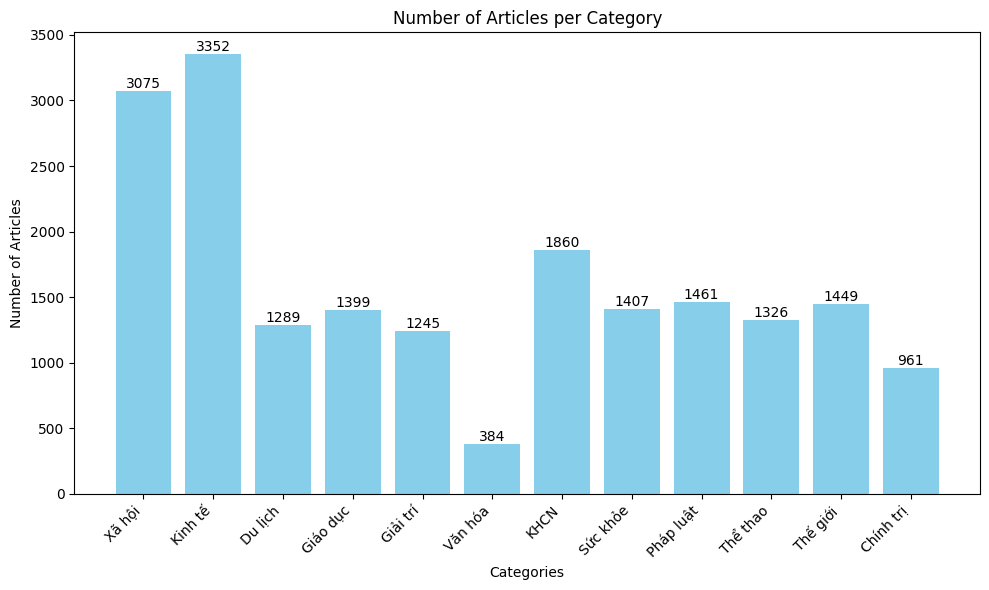

In [8]:
categories = [article['cat'] for article in processed_data]

category_counts = {}
for category in categories:
    if category in category_counts:
        category_counts[category] += 1
    else:
        category_counts[category] = 1

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(category_counts.keys(), category_counts.values(), color='skyblue')

# Thêm số lượng lên đỉnh mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.xlabel('Categories')
plt.ylabel('Number of Articles')
plt.title('Number of Articles per Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Tải vocab

In [9]:
vocab = set()

with open('vocabulary.tex', 'r', encoding='utf-8') as fin:
    for line in fin:
        a = line.split()
        if len(a) == 1:
            word = " "
        else:
            word = a[1]
        vocab.add(word)
    
len(vocab)

189

# Nhóm các bài báo theo từng thể loại

In [10]:
grouped_data = defaultdict(list)

for doc in processed_data:
    cat = doc['cat']
    grouped_data[cat].append({'id': doc['id'], 'content': doc['content']})

# Trích chọn đặc trưng, tạo vector biểu diễn cho dữ liệu

## Dùng TF-IDF

In [11]:
def embeddings_with_tfidf(data):
    data_embeddings = np.zeros((len(data), len(vocab)))
    data_id = []
    
    query = "select * from tfidf where doc_id=%s"

    for i, article in enumerate(data):
        doc_id = article['id']
        data_id.append(doc_id)
        cursor.execute(query, (doc_id,))
        tfidf_values = cursor.fetchall()
        for row in tfidf_values:
            j = int(row[1])
            data_embeddings[i][j] = row[-1]
            
    return data_embeddings, data_id

## Dùng SBert

In [251]:
from sentence_transformers import SentenceTransformer

# Chọn mô hình và chuyển sang GPU
model_sbert = SentenceTransformer('keepitreal/vietnamese-sbert', device=device)

In [252]:
def embeddings_with_sbert(data):
    data_embeddings = []
    data_id = []

    for article in tqdm(data, desc=f"Encoding articles ", unit='article'):
        doc_id = article['id']
        data_id.append(doc_id)
        embedding = model_sbert.encode(article['content'])
        data_embeddings.append(embedding)
        
    return data_embeddings, data_id

# Chạy các thuật toán phân cụm

## Hàm đánh giá chất lượng phân cụm

In [14]:
import warnings
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# Tắt tất cả các cảnh báo FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

def evaluate_clustering(embeddings, labels, model=None):
    sil_score = silhouette_score(embeddings, labels)
    db_score = davies_bouldin_score(embeddings, labels)
    ch_score = calinski_harabasz_score(embeddings, labels)

    # Tính WCSS nếu có model KMeans
    wcss = None
    if model and hasattr(model, 'inertia_'):
        wcss = model.inertia_

    return sil_score, db_score, ch_score, wcss

## Hàm chạy thuật toán phân cụm và đánh giá chất lượng phân cụm

In [15]:
# Chạy và đánh giá chất lượng phân cụm
def cluster_and_evaluate(embeddings, n_clusters_list):
    results = {n: {} for n in n_clusters_list}

    for n_clusters in tqdm(n_clusters_list, desc="Clustering and evaluating"):
        # K-means
        kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(embeddings)
        kmeans_labels = kmeans.labels_
        results[n_clusters]['kmeans'] = evaluate_clustering(embeddings, kmeans_labels, model=kmeans)

        # Hierarchical Clustering
        hier = AgglomerativeClustering(n_clusters=n_clusters).fit(embeddings)
        hier_labels = hier.labels_
        results[n_clusters]['hierarchical'] = evaluate_clustering(embeddings, hier_labels)

    return results

# Hàm vẽ biểu đồ kết quả đánh giá

In [16]:
# Hàm vẽ biểu đồ kết quả đánh giá
def plot_evaluation_results(metrics_dict):
    n_clusters_list = sorted(metrics_dict.keys())

    algorithms = ['kmeans', 'hierarchical']
    metrics = ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index']

    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=False)

    for i, metric in enumerate(metrics):
        ax = axs[i]
        for algo in algorithms:
            scores = [metrics_dict[n][algo][i] for n in n_clusters_list]
            ax.plot(n_clusters_list, scores, marker='o', label=algo)

        ax.set_title(metric)
        ax.set_xlabel('Number of Clusters')
        ax.set_ylabel('Score')
        ax.legend()

        # Đặt giới hạn trục Y cho mỗi metric
        if metric == 'Silhouette Score':
            ax.set_ylim(0, max(max([metrics_dict[n][algo][0] for n in n_clusters_list]) for algo in algorithms) * 1.1)
        elif metric == 'Davies-Bouldin Index':
            ax.set_ylim(0, max(max([metrics_dict[n][algo][1] for n in n_clusters_list]) for algo in algorithms) * 1.1)
        elif metric == 'Calinski-Harabasz Index':
            ax.set_ylim(0, max(max([metrics_dict[n][algo][2] for n in n_clusters_list]) for algo in algorithms) * 1.1)

    plt.tight_layout()
    plt.show()

## Với biểu diễn TF-IDF

### Chạy các thuật toán phân cụm

In [17]:
cat_mapping = {
    "Xã hội": "xa_hoi",
    "Kinh tế": "kinh_te",
    "Du lịch": "du_lich",
    "Giáo dục": "giao_duc",
    "Giải trí": "giai_tri",
    "Văn hóa": "van_hoa",
    "KHCN": "khcn",
    "Sức khỏe": "suc_khoe",
    "Pháp luật": "phap_luat",
    "Thể thao": "the_thao",
    "Thế giới": "the_gioi",
    "Chính trị": "chinh_tri"
}

In [18]:
cluster_results = {}

In [467]:
n_clusters_to_run = range(10, 41)

cat = "Xã hội"
vector = "sbert"
data_embeddings, data_id = embeddings_with_sbert(grouped_data[cat])
    
cluster_results = cluster_and_evaluate(data_embeddings, n_clusters_to_run)

Encoding articles :   0%|          | 0/3075 [00:00<?, ?article/s]

Clustering and evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

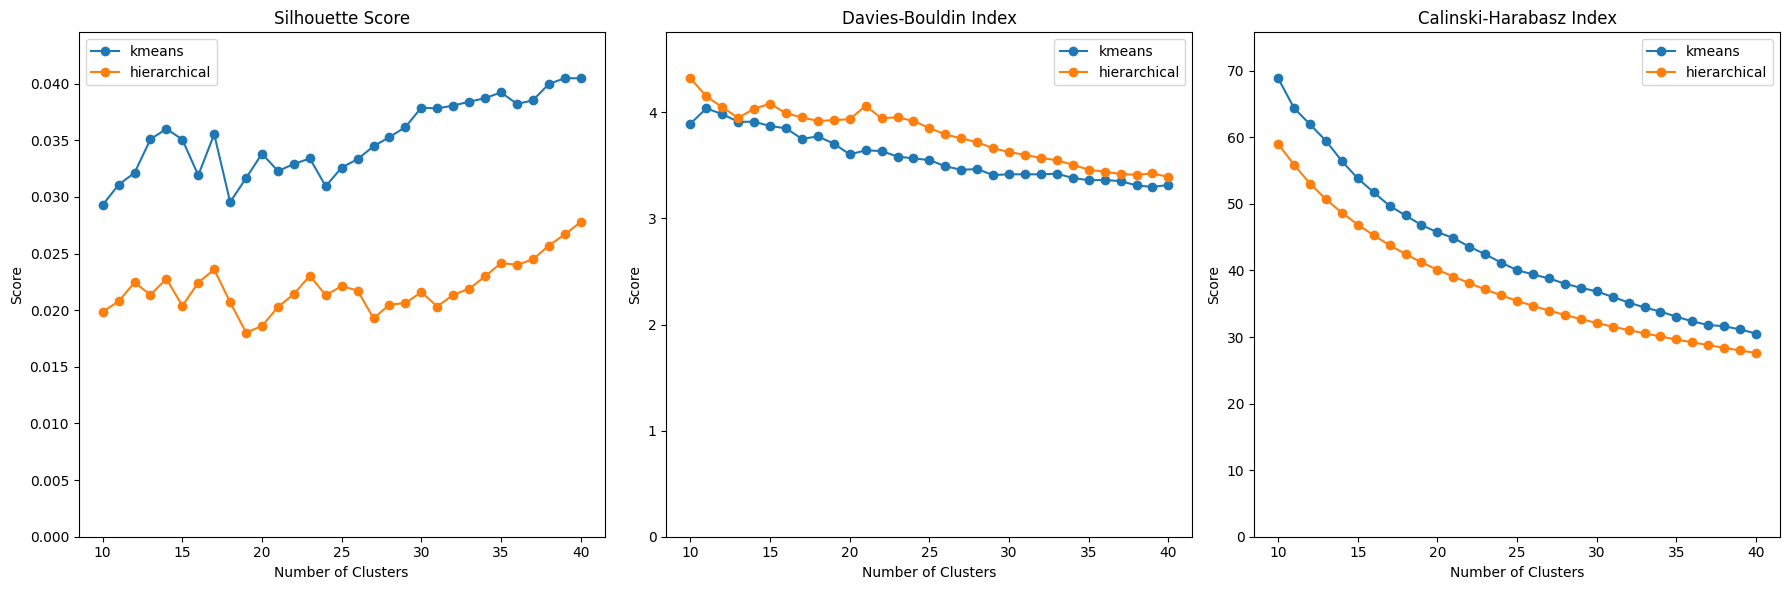

In [468]:
plot_evaluation_results(cluster_results)

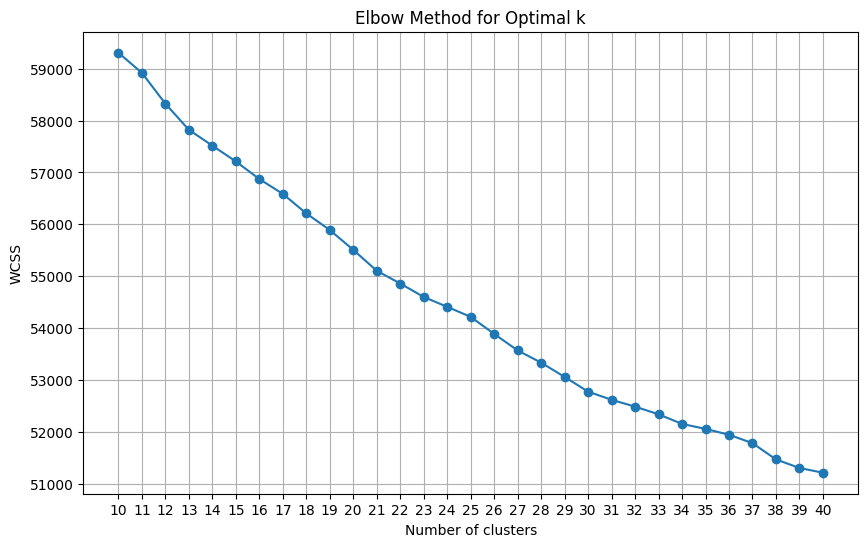

In [469]:
n_list = sorted(cluster_results.keys())
scores = [cluster_results[n]['kmeans'][3] for n in n_list]

plt.figure(figsize=(10, 6))
plt.plot(n_list, scores, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(n_clusters_to_run)
plt.grid(True)
plt.show()

In [470]:
# Lựa chọn số cụm tối ưu
optimal_n_clusters = 40
# Lựa chọn model tối ưu
model = KMeans(n_clusters=optimal_n_clusters, random_state=42).fit(data_embeddings)

In [471]:
labels = model.fit_predict(data_embeddings)

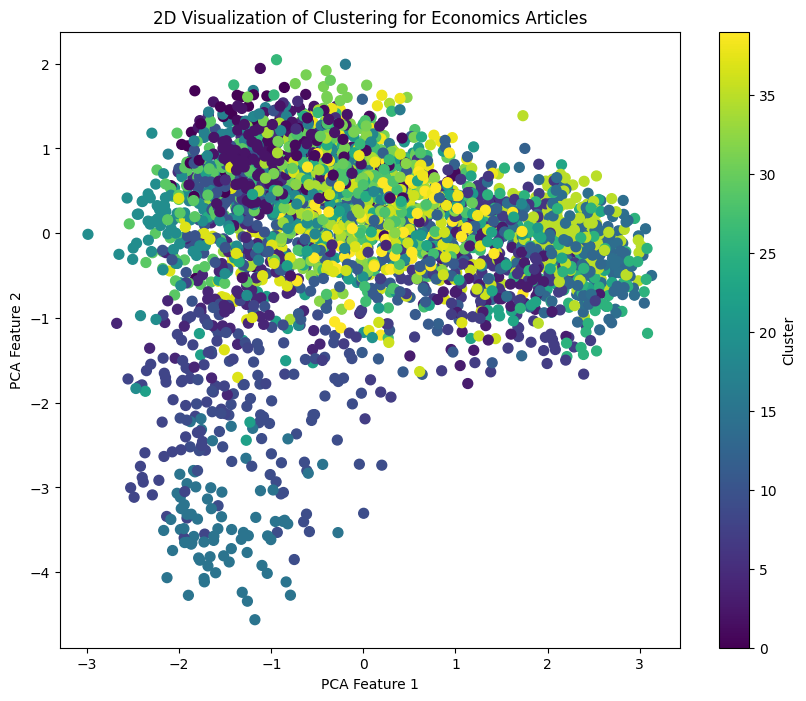

In [472]:
from sklearn.decomposition import PCA

# Giảm chiều dữ liệu xuống 2D bằng PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(data_embeddings)

# Vẽ minh họa việc phân cụm trên đồ thị 2D
plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=labels, cmap='viridis', marker='o', s=50)
plt.colorbar(scatter, label='Cluster')
plt.title('2D Visualization of Clustering for Economics Articles')
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.show()

In [473]:
# Thay `chosen_cluster` bằng số cụm bạn muốn kiểm tra, số bắt đầu từ 0 đến n_clusters - 1
chosen_cluster = 1

# Lọc các bài báo thuộc cụm đã chọn
chosen_cluster_indices = [i for i, label in enumerate(labels) if label == chosen_cluster]
chosen_articles = []
for i in chosen_cluster_indices:
    doc_id = data_id[i]
    for doc in data:
        if doc['id'] == doc_id:
            chosen_articles.append(doc['content'])
            break
    
# chosen_articles = [data[i]['content'] for i in chosen_cluster_indices]

# In ra nội dung của 3 bài báo đầu tiên trong cụm đã chọn
print(f"Nội dung của 3 bài báo trong cụm {chosen_cluster}:")
for i, article in enumerate(chosen_articles[-3:]):
    print(f"Bài báo {i+1}:")
    print(article)
    print("-" * 80)

Nội dung của 3 bài báo trong cụm 1:
Bài báo 1:
Hơn 4h chiều, chị Mai An ở phường Yên Hòa, quận Cầu Giấy rủ con trai ra đường đi bộ ven sông Tô Lịch tập thể dục, điều trước giờ chị hiếm khi thực hiện. Trước đây mỗi khi ra đường người phụ nữ 47 tuổi phải đeo hai lớp khẩu trang, cố gắng nín thở mỗi hôm trời nóng bởi mùi nước thải bốc lên từ dòng nước đen đặc.
"Nhà tôi cách bờ sông 100 m nhưng mỗi khi gió lùa là mùi bay vào tận nhà, nhức đầu. Ngày mưa, mát trời mới dám mở cửa chứ ngày nóng, nước cạn phải đóng chặt", chị An kể.
Nhưng khoảng ba ngày nay, chị chủ động đi dạo trên đường ven sông bởi thấy nước dâng cao, chuyển trong xanh và đặc biệt không có mùi hôi. Chị An nói rất lâu mới có cảm giác thoải mái như thế này.
[Nước sông Tô Lịch chuyển màu xanh ngắt, không còn mùi hôi thối bốc lên, chiều 29/7. Ảnh: Quỳnh Nguyễn]
Ông Trường Quang, 70 tuổi, ở phường Láng Thượng, quận Đống Đa, thường xuyên chở cháu gái đi học qua sông Tô Lịch, cho biết dòng nước bắt đầu đổi màu xanh lục và sạch hơn s

In [474]:
algo = "kmeans"
# algo = "HAC"
table_name =  f"clustering_{cat_mapping[cat]}_using_{algo}_with_{vector}"
table_name

'clustering_xa_hoi_using_kmeans_with_sbert'

In [475]:
create_table_query = f"""
CREATE TABLE IF NOT EXISTS {table_name} (
    doc_id INT NOT NULL,
    label INT NOT NULL,
    PRIMARY KEY (doc_id)
)
"""

cursor.execute(create_table_query)

In [476]:
for i, doc_id in enumerate(data_id):
    query = f"INSERT INTO {table_name} (doc_id, label) VALUES (%s, %s)"
    value = (doc_id, int(labels[i]))
    cursor.execute(query, value)

In [477]:
model_hac = AgglomerativeClustering(n_clusters=optimal_n_clusters).fit(data_embeddings)

In [478]:
labels_hac = model_hac.fit_predict(data_embeddings)

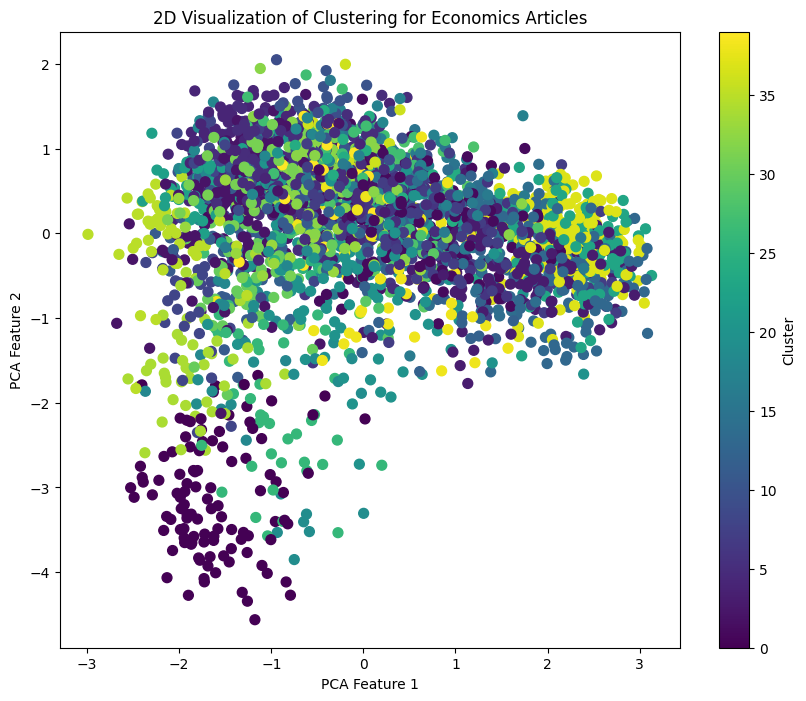

In [479]:
from sklearn.decomposition import PCA

# Giảm chiều dữ liệu xuống 2D bằng PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(data_embeddings)

# Vẽ minh họa việc phân cụm trên đồ thị 2D
plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=labels_hac, cmap='viridis', marker='o', s=50)
plt.colorbar(scatter, label='Cluster')
plt.title('2D Visualization of Clustering for Economics Articles')
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.show()

In [480]:
# Thay `chosen_cluster` bằng số cụm bạn muốn kiểm tra, số bắt đầu từ 0 đến n_clusters - 1
chosen_cluster = 1

# Lọc các bài báo thuộc cụm đã chọn
chosen_cluster_indices = [i for i, label in enumerate(labels_hac) if label == chosen_cluster]
chosen_articles = []
for i in chosen_cluster_indices:
    doc_id = data_id[i]
    for doc in data:
        if doc['id'] == doc_id:
            chosen_articles.append(doc['content'])
            break
    
# chosen_articles = [data[i]['content'] for i in chosen_cluster_indices]

# In ra nội dung của 3 bài báo đầu tiên trong cụm đã chọn
print(f"Nội dung của 3 bài báo trong cụm {chosen_cluster}:")
for i, article in enumerate(chosen_articles[-3:]):
    print(f"Bài báo {i+1}:")
    print(article)
    print("-" * 80)

Nội dung của 3 bài báo trong cụm 1:
Bài báo 1:
Sau khi khám và kiểm tra các chỉ số, người phụ nữ 34 tuổi ở Hà Nội được kết luận đủ điều kiện mổ đẻ, vì đang ở tuần thai thứ 39, sức khỏe mẹ và thai nhi đều ổn. Tuy nhiên cô được khuyên nên sinh thường như lần đầu để tốt cho cả mẹ và con.
''Mua cái quần cái áo còn phải tránh tháng 7 nữa là sinh đứa con", Phương nói và tiếp tục bày tỏ nguyện vọng. Cô gọi điện về quê nhờ bà ngoại đi xem ngày giờ đẹp, đồng thời báo bà nội chuẩn bị ra chăm cháu. Chồng Phương cũng xin phép cơ quan nghỉ chăm vợ.
Hôm 31/7 (tức 26/6 âm lịch), Phương vào viện. Dù đông đúc, tất cả khâu đều phải chờ đợi, cô cũng như nhiều sản phụ khác vẫn hồ hởi. Cùng ngày, vợ chồng cô đã chào đón con gái nặng 3,4 kg, mẹ và con đều khỏe. "Tôi tính ở viện ba ngày để kịp đưa bé về nhà trước 'tháng cô hồn'", Mai Phương nói.
Bác sĩ Lê Duy Toàn, Bệnh viện Phụ sản Hà Nội cho biết, nhiều sản phụ có nhu cầu mổ chủ động để "chạy tháng 7 âm", thậm chí có trường hợp đặt vấn đề mổ chọn ngày chọn

In [481]:
algo = "HAC"
table_name =  f"clustering_{cat_mapping[cat]}_using_{algo}_with_{vector}"
table_name

'clustering_xa_hoi_using_HAC_with_sbert'

In [482]:
create_table_query = f"""
CREATE TABLE IF NOT EXISTS {table_name} (
    doc_id INT NOT NULL,
    label INT NOT NULL,
    PRIMARY KEY (doc_id)
)
"""

cursor.execute(create_table_query)

In [483]:
for i, doc_id in enumerate(data_id):
    query = f"INSERT INTO {table_name} (doc_id, label) VALUES (%s, %s)"
    value = (doc_id, int(labels_hac[i]))
    cursor.execute(query, value)

In [484]:
mydb.commit()